In [1]:
import numpy as np
from noise_seeds import generate_noise
from PIL import Image

#### august 11th

In [2]:
black_frames = np.full((144, 256), fill_value = 0)

In [3]:
dynamic3 = generate_noise('dynamic', 1, 3)
dynamic3 = np.squeeze(dynamic3)

In [4]:
final_array = (black_frames + dynamic3)

In [5]:
final_array

array([[-1.93823671e-03, -2.82569361e+00,  4.53200847e-01, ...,
        -2.82481651e+00,  3.94044460e+00,  1.79602811e+00],
       [-2.86557440e-01, -3.16823459e+00,  2.23278048e+00, ...,
         2.08299178e-01, -1.52665096e+00, -6.33851126e-01],
       [-2.25560295e+00,  4.38298936e+00,  3.50932977e+00, ...,
         2.10211789e+00, -5.52979246e+00, -4.58650904e+00],
       ...,
       [-1.64665198e+00, -2.61901201e+00,  1.75538649e+00, ...,
        -1.73206538e+00,  1.11985395e+00,  1.60585652e+00],
       [ 4.00208513e-01, -3.33190102e+00,  3.62413833e+00, ...,
        -5.54796446e+00,  6.33781219e-01,  3.19893456e+00],
       [ 3.02860432e+00,  3.16277477e+00,  2.02857871e+00, ...,
        -2.21972054e+00,  6.01459221e+00, -5.86330003e-01]])

In [6]:
final_array = np.round(final_array)

In [7]:
final_array

array([[-0., -3.,  0., ..., -3.,  4.,  2.],
       [-0., -3.,  2., ...,  0., -2., -1.],
       [-2.,  4.,  4., ...,  2., -6., -5.],
       ...,
       [-2., -3.,  2., ..., -2.,  1.,  2.],
       [ 0., -3.,  4., ..., -6.,  1.,  3.],
       [ 3.,  3.,  2., ..., -2.,  6., -1.]])

In [8]:
final_image = np.clip(final_array, a_min = 0, a_max = 255)

In [9]:
final_image.shape

(144, 256)

In [10]:
final_image

array([[0., 0., 0., ..., 0., 4., 2.],
       [0., 0., 2., ..., 0., 0., 0.],
       [0., 4., 4., ..., 2., 0., 0.],
       ...,
       [0., 0., 2., ..., 0., 1., 2.],
       [0., 0., 4., ..., 0., 1., 3.],
       [3., 3., 2., ..., 0., 6., 0.]])

In [11]:
image = Image.fromarray(final_image)

In [12]:
image.show()

In [ ]:
np.max(black_frames + dynamic3)

np.float64(12.329142395758344)

#### august 14th

In [2]:
import numpy as np
import pandas as pd
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from scipy.stats import shapiro
from sklearn.linear_model import LinearRegression
from processing import remove_x

def plot_select30_hist(array, title, neurons, color = 'b'): # plots histogram for first image in stack object, specified neurons

    neuron_pvalue = pd.DataFrame({
    'neuron' : [],
    'p_value' :[]
    })

    fig, axes = plt.subplots(5,6, figsize = (20,6))

    array = array[0] # 3d array is going to be inputted, for now just take first image

    p_values = np.empty((neurons.size))
    test_statistics = np.empty((neurons.size))
    for id, neuron in enumerate(neurons):
        row = id // 6
        col = id % 6
        ax = axes[row, col]
        plot = array[:,neuron]
        ax.hist(plot, color = color)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{round(x,3)}"))

        # hypothesis test
        p_value, test_statistic = shapiro(plot)
        p_values[id] = p_value
        test_statistics[id] = test_statistic
        neuron_pvalue.loc[id] = neuron, p_value

    # display histogram
    fig.suptitle(f"Neuron Outputs: {title}")
    fig.supxlabel('Predicted Firing Rate')
    fig.supylabel('Counts')
    plt.tight_layout()
    plt.show()

    # print dataframe with p values
    neuron_pvalue['neuron'] = neuron_pvalue['neuron'].astype(int)
    neuron_pvalue['p_value'] = neuron_pvalue['p_value'].round(3)
    print(neuron_pvalue)

def line_plot_mean(array: np.array, neurons: list | np.ndarray = [i for i in range(100)],
                   specified_image_index: int = None): # input mean/var output from predict_loop()
    """
    Parameters
    ----------
    array: np.array
        mean/var output from predict loop
    neurons: list or np.array
        list of specified neurons to pick, defaults to first 100
    specified_image_index: int
        if inputted will format line plot data for specified image

    Returns
    -------
    final_array
        average output for all images for specified neurons
    """
    final_array = np.empty(shape = len(neurons))
    for i, neuron in enumerate(neurons):
        if specified_image_index is not None: final_array[i] =  array[specified_image_index, neuron] # if input is just one image
        else: final_array[i] = np.mean(array[:, neuron]) # if input is for all images
    return final_array


def spike_plot_4x2(main_title: str, dynamic_array: list, constant_array: list, normalized: bool, # first plot in presentation results
                 image_index: int = 0, sigmas: list = [3, 15, 30], neurons: list = [i for i in range(100)], savefig: bool = False):
    """
    Parameters
    ----------
    dynamic_array: list
        List of lists where each sublist contains arrays of mean/var spike counts 
        for different sigmas across neurons for a region
    constant_array: list
        List of lists where each sublist contains arrays of mean/var spike counts 
        for different sigmas across neurons for a region
    normalized: bool
        If True, normalize values by the response at the first sigma
    image_index: int
        index of image from image prediction stack to plot data for, defaults to 0 (gray frames)
    sigmas: list
        List of sigma values for noise, defaults to [3, 15, 30]
    neurons: list
        List of neurons to plot, defaults to first 100
    num_regions: int
        Number of brain regions from data, defaults to 4
    savefig: bool
        Whether to save figure or not to current directory
    
    Returns
    -------
    matplotlib plot
        4x2 grid of line plots, each row for a region, with dynamic noise in column 0 
        and constant noise in column 1
    """
    
    for arr in [dynamic_array, constant_array]:
        for region in range(len(arr)):
            for region_arr in range(len(arr[region])):
                arr[region][region_arr] = line_plot_mean(arr[region][region_arr], neurons, image_index)

    fig, axes = plt.subplots(2, 4, figsize=(12, 8), sharey=True, sharex=True)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))
    sigmas = np.array(sigmas)
    num_neurons = len(neurons)
    colors = plt.cm.tab20(np.linspace(0, 1, num_neurons))

    for region in range(len(constant_array)):
        ax_dyn = axes[0, region]
        ax_con = axes[1, region]
        dynamic_data = dynamic_array[region]  # List of arrays for sigmas in this region
        constant_data = constant_array[region]

        # Dynamic noise plot
        dynamic_means_y = np.empty((num_neurons, len(sigmas)))
        for neuron in neurons:
            dynamic_y = np.array([dynamic_data[s_idx][neuron] for s_idx in range(len(sigmas))])
            if normalized:
                dynamic_y = dynamic_y / dynamic_data[0][neuron]
            dynamic_means_y[neuron] = dynamic_y
            ax_dyn.plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color=colors[neuron])

        dynamic_mean_plot = np.mean(dynamic_means_y, axis=0)
        model_dyn = LinearRegression(fit_intercept=False)
        model_dyn.fit(sigmas.reshape(-1, 1), dynamic_mean_plot)
        slope_dyn = model_dyn.coef_[0]
        y_pred_dyn = slope_dyn * sigmas
        ax_dyn.plot(sigmas, y_pred_dyn, 'r--', label='Regression line', linewidth=1)
        
        # Calculate standard error of the slope
        residuals = dynamic_mean_plot - y_pred_dyn
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((sigmas - np.mean(sigmas))**2)
        std_err_dyn = np.sqrt(ss_res / (len(sigmas) - 1) / ss_tot)
        dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
        ax_dyn.fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='blue', alpha=1)
        
        ci_dyn = f'[{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]'
        ax_dyn.text(0.05, 0.85, f'Slope: {slope_dyn:.3f}\nCI: {ci_dyn}', transform=ax_dyn.transAxes, ha='left', va='top')
        if normalized: ax_dyn.axhline(y=1, color='black', linestyle='-', linewidth=1)
        
        ax_dyn.set_ylabel(f'Dynamic Noise' + 
                         (f'\n(Normalized by Response at Sigma={sigmas[0]})' if normalized else '') +
                          f'\n\nMean Prediction\nSpike Count', 
                         fontsize=12) if region == 0 else ''
        
        # Constant noise plot
        constant_means_y = np.empty((num_neurons, len(sigmas)))
        for neuron in neurons:
            constant_y = np.array([constant_data[s_idx][neuron] for s_idx in range(len(sigmas))])
            if normalized and constant_data[0][neuron] != 0:
                constant_y = constant_y / constant_data[0][neuron]
            constant_means_y[neuron] = constant_y
            ax_con.plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color=colors[neuron])

        constant_mean_plot = np.mean(constant_means_y, axis=0)
        model_con = LinearRegression(fit_intercept=False)
        model_con.fit(sigmas.reshape(-1, 1), constant_mean_plot)
        slope_con = model_con.coef_[0]
        y_pred_con = slope_con * sigmas
        ax_con.plot(sigmas, y_pred_con, 'r--', label='Regression line', linewidth=1)
        
        # Calculate standard error of the slope
        residuals = constant_mean_plot - y_pred_con
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((sigmas - np.mean(sigmas))**2)
        std_err_con = np.sqrt(ss_res / (len(sigmas) - 1) / ss_tot)
        con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
        ax_con.fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='blue', alpha=1)
        
        ci_con = f'[{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]'
        ax_con.text(0.05, 0.85, f'Slope: {slope_con:.3f}\nCI: {ci_con}', transform=ax_con.transAxes, ha='left', va='top')
        if normalized: ax_con.axhline(y=1, color='black', linestyle='-', linewidth=1)

        ax_con.set_ylabel(f'Constant Noise' + 
                         (f'\n(Normalized by Response at Sigma={sigmas[0]})' if normalized else '') +
                          f'\n\nMean Prediction\nSpike Count', 
                         fontsize=12) if region == 0 else ''

    for col in range(4): axes[1, col].set_xlabel('Sigma for Input Noise')

    # Add legend to each subplot
    for ax in axes.flat:
        ax.legend(loc='upper left')

    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: plt.show()

def sixteen_tuning_curves(arrays: list | np.ndarray, main_title: str, titles: list, ten_neurons: list = [i for i in range(10)], savefig: bool = False): # second plot in presentation results
    """
    Parameters
    ----------
    arrays: list
        list of output arrys to plot (sum arrays from predict loop)
    main_title: str
        main title at top of plot
    titles: list
        list of corresponding titles for each plot
    ten_neurons: list
        list of ten neurons to use, defaults to first ten 
    savefig: bool
        whether or not to save the figure
    
    Returns
        4x4 tuning curves figure
    """
    fig, axes = plt.subplots(4, 4, figsize=(10, 10), sharex=True)
    image_ids = np.array([i for i in range(5)], dtype=int)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))
    fig.text(0.5, -.02, 'Image ID', ha='center', va='bottom', fontsize=12, fontweight = 'bold')

    for i in range(len(arrays)):
        for j in range(len(arrays[0])):
            ax = axes[i,j]
            
            mean_array = np.mean(arrays[i][j], axis=1) 
            variance = np.var(arrays[i][j], axis=1)
            std_dev = np.sqrt(variance)

            for neuron in ten_neurons:
                neuron_predictions = mean_array[:, neuron]
                ax.errorbar(image_ids, neuron_predictions, yerr=std_dev[:, neuron],
                            marker='o', linestyle='-', capsize=5)

            ax.set_title(f"{titles[j]}" if i == 0 else '', fontsize=10)
            ax.set_ylabel("Mean Predicted Spike Count" if j == 0 else '', fontweight = 'bold')
            ax.xaxis.set_major_locator(MultipleLocator(1))
            ax.grid(True)
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: plt.show()

def mean_var_scatter_4x4(means, vars, main_title: str, savefig: bool = False, remove_x_str: str = None, x_percent: int = None): # third plot in presentation results
    fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=False, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=14, fontweight = 'bold', bbox=dict(facecolor='white'))
    sigmas = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']
    
    for i in range(4):
        for j in range(4):
            idx = i * 4 + j
            ax = axes[i, j] # first iterate j through different sigmas
            
            x = means[i][j]
            y = vars[i][j]

            x = x.flatten()
            y = y.flatten()

            model = LinearRegression(fit_intercept=False)
            model.fit(x.reshape(-1, 1), y)
            slope = model.coef_[0]
            x_fit = np.linspace(np.min(x), np.max(x), len(x))
            y_fit = slope * x_fit
            
            # Calculate standard error of the slope
            y_pred = slope * x
            residuals = y - y_pred
            ss_res = np.sum(residuals**2)
            ss_tot = np.sum((x - np.mean(x))**2)
            std_err = np.sqrt(ss_res / (len(x) - 1) / ss_tot)
            se_fit = std_err * np.sqrt(1/len(x) + (x_fit - np.mean(x))**2 / np.sum((x - np.mean(x))**2))

            if remove_x_str is not None and x_percent is not None:                  
                remove = remove_x(y, remove_x_str, x_percent).astype(int)
                x = x[remove]
                y = y[remove]
                ax.set_ylim(0, np.max(y))
                ax.set_xlim(0,  np.max(x))
            cmap = plt.get_cmap('plasma')
            colors = cmap(np.linspace(0, .95, len(x)))         
            
            ax.scatter(x, y, marker='.', color = colors, alpha = 0.7)
            ax.plot(x_fit, y_fit, 'r--', label='Regression line', linewidth=2)           
            ax.fill_between(x_fit, y_fit - 1.96 * se_fit, y_fit + 1.96 * se_fit, color = 'blue', alpha = 1)

            # Calculate R-squared
            ss_res = np.sum((y - y_pred)**2)
            ss_tot = np.sum((y - np.mean(y))**2)
            r_squared = 1 - ss_res / ss_tot if ss_tot != 0 else 0

            confidence_interval = f'[{slope - 1.96*std_err:.3f}, {slope + 1.96*std_err:.3f}]'
            ax.text(0, 1, f'Slope: {slope:.3f}\nCI: {confidence_interval}\nR-Squared: {r_squared:.3f}',
                    fontsize = '6', ha = 'left',  va = 'top', transform=ax.transAxes)

            ax.grid(True)

            if i == 0: title_region = 'V1' 
            elif i == 1: title_region = 'LM'
            elif i == 2: title_region = 'AL'
            else: title_region = 'RL'

            if j == 0: ax.set_ylabel(f'Variance in\nPredicted Spike Count', fontsize = 11)
            
            if i == 0: ax.set_title(f'({sigmas[j]})\n', fontsize = 10)
            elif i == 3: ax.set_xlabel('Mean Predicted\nSpike Count', fontsize = 12)  
    
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: plt.show()

def mean_var_scatter_4x4_regression(means, vars, neurons, main_title: str, savefig: bool = False): # fourth plot in presentation results
    """
    Parameters
    ----------
    means: list
        list of mean arrays, must be 2d list
    vars: list
        list of varriance arrays, must be 2d list
    neurons: list
        ten neurons to plot
    main_title: str
        title for plot
    savefig: bool
        whether or not to save figure, defaults image to same directory

    Returns
        4x4 mean versus variance lineplot for selected neurons 
    """
    
    fig, axes = plt.subplots(4, 4, figsize=(12, 10), sharex=False, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))
    sigmas = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']
    
    for i in range(4):
        neuron_arr = neurons[i]
        for j in range(4):
            idx = i * 4 + j
            ax = axes[i, j] # first iterate j through different sigmas
            

            x = np.array(means[i][j])
            y = np.array(vars[i][j])
            for neuron in neuron_arr:
                x_neuron = x[:, neuron]
                y_neuron = y[:, neuron]
                
                cmap = plt.get_cmap('plasma')

                color_i = neuron_arr.index(neuron) / (len(neuron_arr) - 1)
                colors = cmap(color_i)
                               
                ax.scatter(x_neuron, y_neuron, marker='.', color = colors, alpha = 0.4)

                model = LinearRegression(fit_intercept=False)
                model.fit(x_neuron.reshape(-1, 1), y_neuron)
                slope = model.coef_[0]
                x_fit = np.linspace(np.min(x_neuron), np.max(x_neuron), len(x_neuron))
                y_fit = slope * x_fit

                ax.plot(x_fit, y_fit, color=colors, label='Regression line', linewidth=2)           
                
                ax.grid(True)

                if i == 0: title_region = 'V1' 
                elif i == 1: title_region = 'LM'
                elif i == 2: title_region = 'AL'
                else: title_region = 'RL'

                if j == 0: ax.set_ylabel(f'Variance in\nPredicted Spike Count', fontsize = 11)
                
                if i == 0: ax.set_title(f'({sigmas[j]})', fontsize = 10)
                elif i == 3: ax.set_xlabel('Mean Predicted\nSpike Count', fontsize = 12)  
    
    fig.text(0, -0.01, 'Note: Colors represent same neuron within each region.', 
             ha='left', va='bottom', fontsize=12)


    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: plt.show()

def violin_4row(means, vars, main_title: str, savefig: bool = False, remove_x_str: str = None, remove_x_percent: int = None): # first violin plot in presentation results
    """
    Parameters
    ----------
    means: list
        list of mean arrays, must be 2d list
    vars: list
        list of varriance arrays, must be 2d list
    main_title: str
        main title for plot
    savefig: bool
        to save figure in current directory, defaults to False
    remove_x_str: str
        to remove top, bottom or None % of data, defaults to None
    remove_x_percent: int
        to remove x % of data, defaults to None

    Returns
    -------
    plot
        4x4 violin plot for each region and sigma/binarization (region 3 excluded)
    """
    
    fig, axes = plt.subplots(len(means), 1, figsize=(10, 8), sharex=True, sharey=False)
    fig.text(0.5, 1.02, main_title, ha='center', va='top', fontsize=12, fontweight = 'bold', bbox=dict(facecolor='white'))
    violin_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
    violin_colors = [violin_colors[i] for i in range(len(means))]
    for i in range(len(means)):
        ax = axes[i] 
        
        region_x = means[i]
        region_y = vars[i]
        slope_list = []

        for mean_arr, var_arr in zip(region_x, region_y):
            slope_temp = []
            for neuron in range(mean_arr.shape[1]):
                neuron_x = mean_arr[:, neuron]
                neuron_y = var_arr[:, neuron]
                model = LinearRegression(fit_intercept=False)
                model.fit(neuron_x.reshape(-1, 1), neuron_y)
                slope_temp.append(model.coef_[0])
            slope_list.append(slope_temp)
        
        # method 1, remove x
        if remove_x_str is not None and remove_x_percent is not None:
            for region_slopes in slope_list:
                region_slopes = remove_x(region_slopes, remove_x_str, remove_x_percent)

        vp = ax.violinplot(slope_list, showmeans = False, showmedians = True, showextrema = False,
                           quantiles = [[0.25, 0.75] for _ in range(len(slope_list))])

        vp['cquantiles'].set_color('black')  
        vp['cquantiles'].set_linewidth(0.25)

        for body in vp['bodies']:
            body.set_facecolor(violin_colors[i])
        for element in ['cmedians']:
            vp[element].set_color('black')
                
        for element in ['cquantiles', 'cmedians']: vp[element].set_linewidth(0.5)

        if i == 0: title_region = 'V1' 
        elif i == 1: title_region = 'LM'
        elif i == 2: title_region = 'AL'
        else: title_region = 'RL'

        ax.set_ylabel(f'(Region: {title_region})\nRegression Slope', fontsize = 10)
        
        tick_labels = ['15', '30', 'Stochastic\nBinarization']
        if i == 3: ax.set_xticks([i+1 for i, _ in enumerate(tick_labels)])
        if i == 3: ax.set_xticklabels(tick_labels)  
        if i == 3: ax.set_xlabel('Sigma + Binarization')
        
        # method 2, set y_lim (adjusting differently for D and C plots)
        if i == 0 or i == 1: ax.set_ylim( min([np.min(arr) for arr in slope_list]), 0.05 * max([np.max(arr) for arr in slope_list]))
        elif i == 2: ax.set_ylim(min([np.min(arr) for arr in slope_list]), 0.2 * max([np.max(arr) for arr in slope_list]))
        else: ax.set_ylim(.1 * min([np.min(arr) for arr in slope_list]), 0.2 * max([np.max(arr) for arr in slope_list]))
    
    plt.text(0, -.45, 'Note: lines within each plot show the interquartile range and median.')
    plt.tight_layout()
    if savefig: 
        try:
            date = datetime.now()
            file_date = f'({str(date.month)}-{str(date.day)}-{str(date.year)})'
            path_name = f'{main_title}_{file_date}.pdf'
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name), 
                        bbox_inches = 'tight', pad_inches = 0.3)
        except FileNotFoundError:
            os.makedirs(f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', exist_ok = True)
            plt.savefig(os.path.join(os.getcwd(), f'plots//({str(date.month)}-{str(date.day)}-{str(date.year)})', path_name),
                        bbox_inches = 'tight', pad_inches = 0.3)
            plt.close()
    else: plt.show()

def violin_combined(means, vars, main_title: str, savefig: bool = False): # second violin plot in presentation
    """
    Parameters
    ----------
    means: list
        list of mean arrays, must be 2d list
    vars: list
        list of varriance arrays, must be 2d list
    main_title: str
        main title for plot
    savefig: bool
        to save figure in current directory, defaults to False
    
    Returns
    -------
    plot
        combined violin plot for each region and sigma/binarization with each region on one figure
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    regions = ['V1', 'LM', 'AL', 'RL']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
    
    all_slope_lists = []
    for i in range(len(means)):
        region_x = means[i]
        region_y = vars[i]
        slope_list = []
        
        for mean_arr, var_arr in zip(region_x, region_y):
            slope_temp = []
            for neuron in range(mean_arr.shape[1]):
                neuron_x = mean_arr[:, neuron]
                neuron_y = var_arr[:, neuron]
                model = LinearRegression(fit_intercept=False)
                model.fit(neuron_x.reshape(-1, 1), neuron_y)
                slope_temp.append(model.coef_[0])
            slope_list.append(slope_temp)
        all_slope_lists.append(slope_list)
    
    num_conditions = len(all_slope_lists[0])
    violin_data = []
    positions = []
    violin_colors = []
    for cond in range(num_conditions):
        for region_idx in range(len(regions)):
            violin_data.append(all_slope_lists[region_idx][cond])
            base_pos = cond + 1  
            offset = (region_idx - (len(regions) - 1) / 2) * 0.2 
            positions.append(base_pos + offset)
            violin_colors.append(colors[region_idx])
    
    vp = ax.violinplot(violin_data, positions=positions, showextrema = False, quantiles = [[0.25, 0.75] for _ in range(len(violin_data))],
                       showmeans=True, showmedians=True, widths=0.2, bw_method = 0.8)
    
    for i, body in enumerate(vp['bodies']):
        body.set_facecolor(violin_colors[i])
        body.set_edgecolor('black')
        body.set_alpha(0.7)
    
    vp['cmeans'].set_color('yellow')
    vp['cmedians'].set_color('white')
    
    ax.set_xticks(range(1, num_conditions + 1))
    ax.set_xticklabels(['3', '15', '30', 'Stochastic\nBinarization'])
    ax.set_xlabel('Sigma + Binarization', fontsize=10)
    
    ax.set_ylabel('Regression Slope', fontsize=10)
    
    legend_elements = [plt.Line2D([0], [0], color=colors[i], lw=4, label=regions[i]) for i in range(len(regions))]
    ax.legend(handles=legend_elements, title='Regions', loc='upper right')
    
    ax.set_title(main_title, fontsize=12, fontweight='bold', pad=10)
    
    plt.ylim(.75 * min([np.min(x) for x in violin_data]), .08 * max([np.max(x) for x in violin_data]))

    plt.tight_layout()
    
    if savefig:
        date = datetime.now()
        file_date = f'({date.year}-{date.month}-{date.day})'
        path_name = f'{main_title}_{file_date}.pdf'
        plt.savefig(os.path.join(os.getcwd(), 'plots', path_name))
    else:
        plt.show()

In [3]:
labels_lst = [1,2,3,4]

string_path = 'fnn//input_noise//saved_inputs_outputs//predictions_july21//' # ex. path to predictions used from july

for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_noise in ['_sum', '_mean', '_var', '_labels']:
        file_name = string_path + noise + type_noise + '.npy'
        arr_name = noise + type_noise
        globals()[arr_name] = np.load(file_name)

# load predictions by region
for r in labels_lst:
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type_noise in ['_sum', '_mean', '_var']:
            file_name = string_path + noise + type_noise + '_r' + str(r) + '.npy'
            arr_name = noise + type_noise + '_r' + str(r)
            globals()[arr_name] = np.load(file_name)

In [4]:
dmeans1 = [[d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1],
                 [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2],
                 [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3],
                 [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]]

dvars1 = [[d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1],
               [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2],
               [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3],
               [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]]


In [7]:
r1_randoms = [2322, 3279, 4060, 1756,  146, 4441, 3978, 2034, 5025, 3515, 3534,
       2167, 2310, 1837, 3864, 2529, 4127, 2325, 4791,  314, 3371, 1857,
       1095, 1917, 3097, 1722, 4344, 3627, 3930, 3459]
# region 2
r2_randoms = [958, 907, 514, 432, 594, 385, 184, 368, 525, 351, 302, 551, 550,
       575, 375, 719, 242, 613, 789, 872, 340, 402, 397, 643, 255, 928,
       471, 894, 281, 523]
# region 3
r3_randoms = [279, 337, 208, 128,  46, 115, 248, 197,  52, 269,  37, 364, 340,
       203,  36, 153,  84, 278,  71, 115,  24,  78, 138,  38,  22,  17,
        89, 349, 178, 332]
# region 4
r4_randoms = [376, 295, 517,  25, 663, 429, 427, 651, 133, 500, 689, 266, 470,
       424,  90, 560, 290, 198, 149, 181, 749, 461, 658, 771, 367, 758,
       125, 195, 191,   8]

randoms_lst = [r1_randoms, r2_randoms, r3_randoms, r4_randoms]

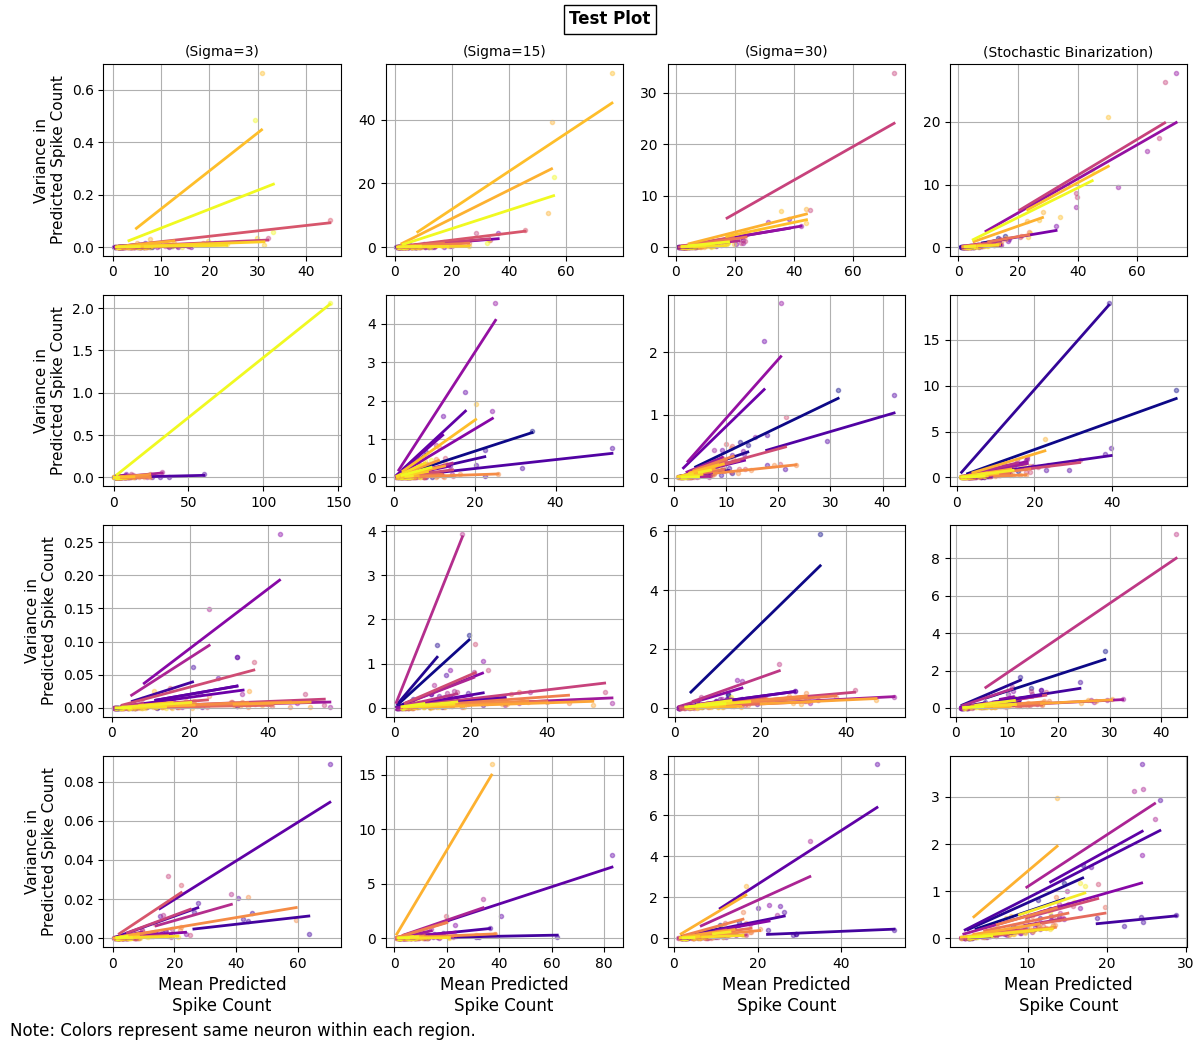

In [9]:
mean_var_scatter_4x4_regression(dmeans1, dvars1, randoms_lst, 'Test Plot')